In [1]:
import pandas as pd 
import numpy as np

def build_rolling_window_cohort(date_suffix="27Mar2026", window_months=24, fuzzy_tolerance=3):
    print(f"Building Rolling-Window Cohort ({window_months}-mo horizon, {fuzzy_tolerance}-mo tolerance)...")
    
    # --- [Data Loading & Renaming as before] ---
    df_my = pd.read_csv(f'../data/adni/raw_data/All_Subjects_My_Table_{date_suffix}.csv', low_memory=False)
    df_dx = pd.read_csv(f'../data/adni/raw_data/All_Subjects_DXSUM_{date_suffix}.csv', low_memory=False)
    df_demo = pd.read_csv(f'../data/adni/raw_data/All_Subjects_PTDEMOG_{date_suffix}.csv', low_memory=False)
    df_adas = pd.read_csv(f'../data/adni/raw_data/All_Subjects_ADAS_{date_suffix}.csv', low_memory=False)
    
    for df in [df_dx, df_demo, df_adas]:
        df.rename(columns={'VISCODE': 'visit', 'PTID': 'subject_id'}, inplace=True)

    def get_month(v):
        v = str(v).lower().strip()
        if v in ['bl', 'sc']: return 0
        if v.startswith('m'):
            try: return int(v.replace('m', ''))
            except: return -1
        return -1

    df_my['month'] = df_my['visit'].apply(get_month)
    df_dx['month'] = df_dx['visit'].apply(get_month)
    df_adas['month'] = df_adas['visit'].apply(get_month)
    
    # 2. Get Static Demographics from PTDEMOG (Gender, Education)
    print("Extracting static demographics from PTDEMOG...")
    bl_demo = df_demo.sort_values(['subject_id', 'visit']).groupby('subject_id').first().reset_index()
    demo_cols = ['subject_id', 'PTGENDER', 'PTEDUCAT']
    bl_demo = bl_demo[[c for c in demo_cols if c in bl_demo.columns]]

    # 3. Fuse Longitudinal Features (including Age and APOE from My_Table)
    print("Fusing longitudinal features and genetic data...")
    
    # Identify which columns are actually in My_Table
    # We look for Age (entry_age) and APOE4 here
    my_cols = ['subject_id', 'visit', 'month', 'entry_research_group', 'entry_age', 'MMSCORE', 'CDRSB', 'FAQTOTAL', 'MOCA', 'NPISCORE', 'GENOTYPE']

    
    long_features = df_my[my_cols].copy()

    long_features['age_at_visit'] = long_features['entry_age'] + (long_features['month'] / 12)

    
    long_adas = df_adas[['subject_id', 'month', 'TOTAL13']].drop_duplicates(subset=['subject_id', 'month'])
    long_features = long_features.merge(long_adas, on=['subject_id', 'month'], how='left')
    


    # Merge Gender and Education from the PTDEMOG subset we made
    long_features = long_features.merge(bl_demo, on='subject_id', how='left')

    # ---------------------------------------------------------
    # CONSOLIDATE SC/BL (MONTH 0)
    # ---------------------------------------------------------
    print("Consolidating 'sc' and 'bl' visits to maximize Baseline features...")
    
    # Define clinical columns that might be split between sc and bl
    clin_cols = my_cols[4:]  # Assuming first 4 cols are subject_id, visit, month, entry_research_group
    
    # 1. Sort to ensure 'sc' (screening) is processed before 'bl' (baseline)
    long_features = long_features.sort_values(['subject_id', 'month', 'visit'])
    
    # 2. Within each patient's Month 0, fill NAs using both rows
    # (e.g., if MMSE is in 'sc' and ADAS is in 'bl', the 'bl' row will now have both)
    m0_mask = long_features['month'] == 0
    long_features.loc[m0_mask, clin_cols] = long_features[m0_mask].groupby('subject_id')[clin_cols].ffill().bfill()
    
    # 3. Drop the 'sc' row, keeping the 'bl' row which now has the combined data
    # If they have both, we keep 'last' (usually the 'bl' visit)
    long_features = long_features.drop_duplicates(subset=['subject_id', 'month'], keep='last')
    
    # ---------------------------------------------------------
    # --- [Label Generation] ---
    valid_rows = []
    dx_grouped = dict(tuple(df_dx.groupby('subject_id')))
    
    for idx, row in long_features.iterrows():
        subj = row['subject_id']
        current_month = row['month']
        if current_month < 0 or subj not in dx_grouped: continue
        
        patient_dx = dx_grouped[subj]
        
        # ---------------------------------------------------------
        # DYNAMIC GATEKEEPER: Strict (0) or Fuzzy (>0)
        # ---------------------------------------------------------
        if fuzzy_tolerance == 0:
            # Strict mode: Exact match only
            current_dx_row = patient_dx[patient_dx['month'] == current_month]
        else:
            # Fuzzy mode: Look for nearest record within the tolerance window
            window = patient_dx[
                (patient_dx['month'] >= current_month - fuzzy_tolerance) & 
                (patient_dx['month'] <= current_month + fuzzy_tolerance)
            ].copy()
            
            if not window.empty:
                window['dist'] = (window['month'] - current_month).abs()
                current_dx_row = window.sort_values('dist').head(1)
            else:
                current_dx_row = pd.DataFrame() # Empty if nothing in window

        # --- Check if they are MCI at this point ---
        is_mci_now = False
        if not current_dx_row.empty:
            target_row = current_dx_row.iloc[0]
            # Harmonized ADNI check: 2 = MCI
            if 'DIAGNOSIS' in target_row.index and target_row['DIAGNOSIS'] == 2:
                is_mci_now = True
        
        if not is_mci_now: continue
            
        # ---------------------------------------------------------
        # LABELING (Window-based)
        # ---------------------------------------------------------
        target_month = current_month + window_months
        future_window = patient_dx[(patient_dx['month'] > current_month) & (patient_dx['month'] <= target_month)]
        
        # Harmonized ADNI check: 3 = Dementia/AD
        if 'DIAGNOSIS' in future_window.columns and 3 in future_window['DIAGNOSIS'].values: 
            row['label'] = 1
            
            # --- NEW: Track exact distance to conversion ---
            conversion_rows = future_window[future_window['DIAGNOSIS'] == 3]
            first_conversion_month = conversion_rows['month'].min()
            row['months_to_conversion'] = first_conversion_month - current_month
            
            valid_rows.append(row)
        else:
            # Stable: Must have stayed in study for at least (Window - Tolerance)
            if patient_dx['month'].max() >= (target_month - fuzzy_tolerance):
                row['label'] = 0
                row['months_to_conversion'] = -1  # Use -1 to represent Stable
                valid_rows.append(row)

    final_df = pd.DataFrame(valid_rows)
    def encode_apoe(genotype):
        genotype = str(genotype)
        if '4/4' in genotype: return 2
        if '4' in genotype: return 1
        return 0

    final_df['APOE4_count'] = final_df['GENOTYPE'].apply(encode_apoe)
    # Drop the original string column
    final_df.drop(columns=['GENOTYPE'], inplace=True, errors='ignore')

    
    
    # ---------------------------------------------------------
    # NEW: VISIT COUNT AUDIT
    # ---------------------------------------------------------
    print("\n" + "="*50)
    print("LONGITUDINAL VISIT AUDIT")
    print("="*50)
    
    visit_counts = final_df['subject_id'].value_counts()
    
    print(f"Total Training Rows:      {len(final_df)}")
    print(f"Unique Patients:          {len(visit_counts)}")
    print(f"Average Rows per Patient: {visit_counts.mean():.2f}")
    print(f"Max Rows from one Patient: {visit_counts.max()}")
    print(f"Min Rows from one Patient: {visit_counts.min()}")
    
    print("\n--- Rows per Patient Distribution ---")
    dist = visit_counts.value_counts().sort_index()
    print(f"{'Rows':<10} | {'Number of Patients'}")
    print("-" * 30)
    for num_rows, num_patients in dist.items():
        print(f"{num_rows:<10} | {num_patients}")
        
    print("\n" + "="*50)
    print(f"Prior (Prevalence): {round(final_df['label'].mean(), 3)}")
    print("="*50)
    
    final_df.set_index(['subject_id', 'month'], inplace=True)
    return final_df

window_months = 36
rolling_dataset = build_rolling_window_cohort(date_suffix="27Mar2026", window_months=window_months)

Building Rolling-Window Cohort (36-mo horizon, 3-mo tolerance)...
Extracting static demographics from PTDEMOG...
Fusing longitudinal features and genetic data...
Consolidating 'sc' and 'bl' visits to maximize Baseline features...

LONGITUDINAL VISIT AUDIT
Total Training Rows:      883
Unique Patients:          316
Average Rows per Patient: 2.79
Max Rows from one Patient: 6
Min Rows from one Patient: 1

--- Rows per Patient Distribution ---
Rows       | Number of Patients
------------------------------
1          | 92
2          | 51
3          | 78
4          | 37
5          | 41
6          | 17

Prior (Prevalence): 0.655


APPLY LOCF

In [2]:
def prep_and_save_data(rolling_df):
    df = rolling_df.copy()
    
    print("Applying patient-specific forward-fill (LOCF)...")
    # Sort chronologically so forward-fill works correctly
    df = df.sort_values(['subject_id', 'month'])
    
    # Safely impute longitudinally 
    clinical_scores = ['TOTAL13', 'MMSCORE', 'CDRSB', 'FAQTOTAL', 'MOCA']
    df[clinical_scores] = df.groupby('subject_id')[clinical_scores].ffill()

    
    return df

# --- RUN IT ---
final_df = prep_and_save_data(rolling_dataset)

Applying patient-specific forward-fill (LOCF)...


Drop duplicate columns

In [3]:
cols_to_drop = [
    'month',                # Use age_at_visit instead to avoid study-duration leakage
    'visit',                # Metadata only
    'entry_age',            # Redundant with age_at_visit
    'AGE',                  # Redundant with age_at_visit
    'entry_research_group'  # We already filtered for MCI; this is now administrative noise
]

final_features_df = final_df.drop(columns=[c for c in cols_to_drop if c in rolling_dataset.columns])

print(f"Post-cleanup columns: {final_features_df.columns.tolist()}")

Post-cleanup columns: ['MMSCORE', 'CDRSB', 'FAQTOTAL', 'MOCA', 'NPISCORE', 'age_at_visit', 'TOTAL13', 'PTGENDER', 'PTEDUCAT', 'label', 'months_to_conversion', 'APOE4_count']


Features check

In [4]:
# For each feature check its distribution, missingness, and relationship with the label, if outliers are present, check if they are real or data errors, and decide how to handle them (e.g., capping, transformation, or removal).
for feature in [ 'MMSCORE', 'CDRSB', 'FAQTOTAL', 'MOCA', 
                   'NPISCORE', 'age_at_visit', 'TOTAL13', 'PTGENDER', 'PTEDUCAT', 
                   'APOE4_count', 'label', 'months_to_conversion']:
    print(f"\n--- Feature: {feature} ---")
    print(f"Distribution:\n{final_features_df[feature].describe()}")
    print(f"Missing Values: {final_features_df[feature].isnull().sum()}")
    print(f"Relationship with Label:\n{final_features_df.groupby('label')[feature].describe()}")



--- Feature: MMSCORE ---
Distribution:
count    883.000000
mean      26.771234
std        2.193008
min       16.000000
25%       25.000000
50%       27.000000
75%       29.000000
max       30.000000
Name: MMSCORE, dtype: float64
Missing Values: 0
Relationship with Label:
       count       mean       std   min   25%   50%   75%   max
label                                                          
0      305.0  27.842623  1.801357  20.0  27.0  28.0  29.0  30.0
1      578.0  26.205882  2.171383  16.0  25.0  26.0  28.0  30.0

--- Feature: CDRSB ---
Distribution:
count    883.000000
mean       1.936014
std        1.120129
min        0.000000
25%        1.000000
50%        1.500000
75%        2.500000
max        7.000000
Name: CDRSB, dtype: float64
Missing Values: 0
Relationship with Label:
       count      mean       std  min  25%  50%  75%  max
label                                                    
0      305.0  1.326230  0.787004  0.0  1.0  1.0  1.5  5.0
1      578.0  2.257785  1.13

ADNI represent missing data for Gender  and Education with -4, so we need to replace those with NaN for proper handling of missing values.

In [5]:
final_features_df['PTGENDER'] = final_features_df['PTGENDER'].replace(-4, np.nan)
final_features_df['PTEDUCAT'] = final_features_df['PTEDUCAT'].replace(-4, np.nan)

Map Gender to binary values

In [6]:
# Explicitly map 1 -> 0 (Male) and 2 -> 1 (Female)
final_features_df['PTGENDER'] = final_features_df['PTGENDER'].replace({1: 0, 2: 1})

# Quick verification
print(final_features_df['PTGENDER'].value_counts(dropna=False))

PTGENDER
0.0    543
1.0    289
NaN     51
Name: count, dtype: int64


Store the dataframe

In [7]:
final_features_df[[ 'MMSCORE', 'CDRSB', 'FAQTOTAL', 'MOCA', 
                   'NPISCORE', 'age_at_visit', 'TOTAL13', 'PTGENDER', 'PTEDUCAT', 
                   'APOE4_count', 'label', 'months_to_conversion']].to_csv(f"../data/adni/adni_rolling_locf_{window_months}m.csv", index=True)

Extract only baseline visits and store the baseline dataset

In [8]:
baseline_dataset = final_features_df.xs(0, level='month', drop_level=False)
baseline_dataset[['MMSCORE', 'CDRSB', 'FAQTOTAL', 'MOCA', 
                   'NPISCORE', 'age_at_visit', 'TOTAL13', 'PTGENDER', 'PTEDUCAT', 
                   'APOE4_count', 'label', 'months_to_conversion']].to_csv(f"../data/adni/adni_baseline_only_{window_months}m.csv", index=True)

Final features check

In [9]:
# For each feature check its distribution, missingness, and relationship with the label, if outliers are present, check if they are real or data errors, and decide how to handle them (e.g., capping, transformation, or removal).
for feature in [ 'MMSCORE', 'CDRSB', 'FAQTOTAL', 'MOCA', 
                   'NPISCORE', 'age_at_visit', 'TOTAL13', 'PTGENDER', 'PTEDUCAT', 
                   'APOE4_count', 'label', 'months_to_conversion']:
    print(f"\n--- Feature: {feature} ---")
    print(f"Distribution:\n{final_features_df[feature].describe()}")
    print(f"Missing Values: {final_features_df[feature].isnull().sum()}")
    print(f"Relationship with Label:\n{final_features_df.groupby('label')[feature].describe()}")



--- Feature: MMSCORE ---
Distribution:
count    883.000000
mean      26.771234
std        2.193008
min       16.000000
25%       25.000000
50%       27.000000
75%       29.000000
max       30.000000
Name: MMSCORE, dtype: float64
Missing Values: 0
Relationship with Label:
       count       mean       std   min   25%   50%   75%   max
label                                                          
0      305.0  27.842623  1.801357  20.0  27.0  28.0  29.0  30.0
1      578.0  26.205882  2.171383  16.0  25.0  26.0  28.0  30.0

--- Feature: CDRSB ---
Distribution:
count    883.000000
mean       1.936014
std        1.120129
min        0.000000
25%        1.000000
50%        1.500000
75%        2.500000
max        7.000000
Name: CDRSB, dtype: float64
Missing Values: 0
Relationship with Label:
       count      mean       std  min  25%  50%  75%  max
label                                                    
0      305.0  1.326230  0.787004  0.0  1.0  1.0  1.5  5.0
1      578.0  2.257785  1.13

Fast feature analysis

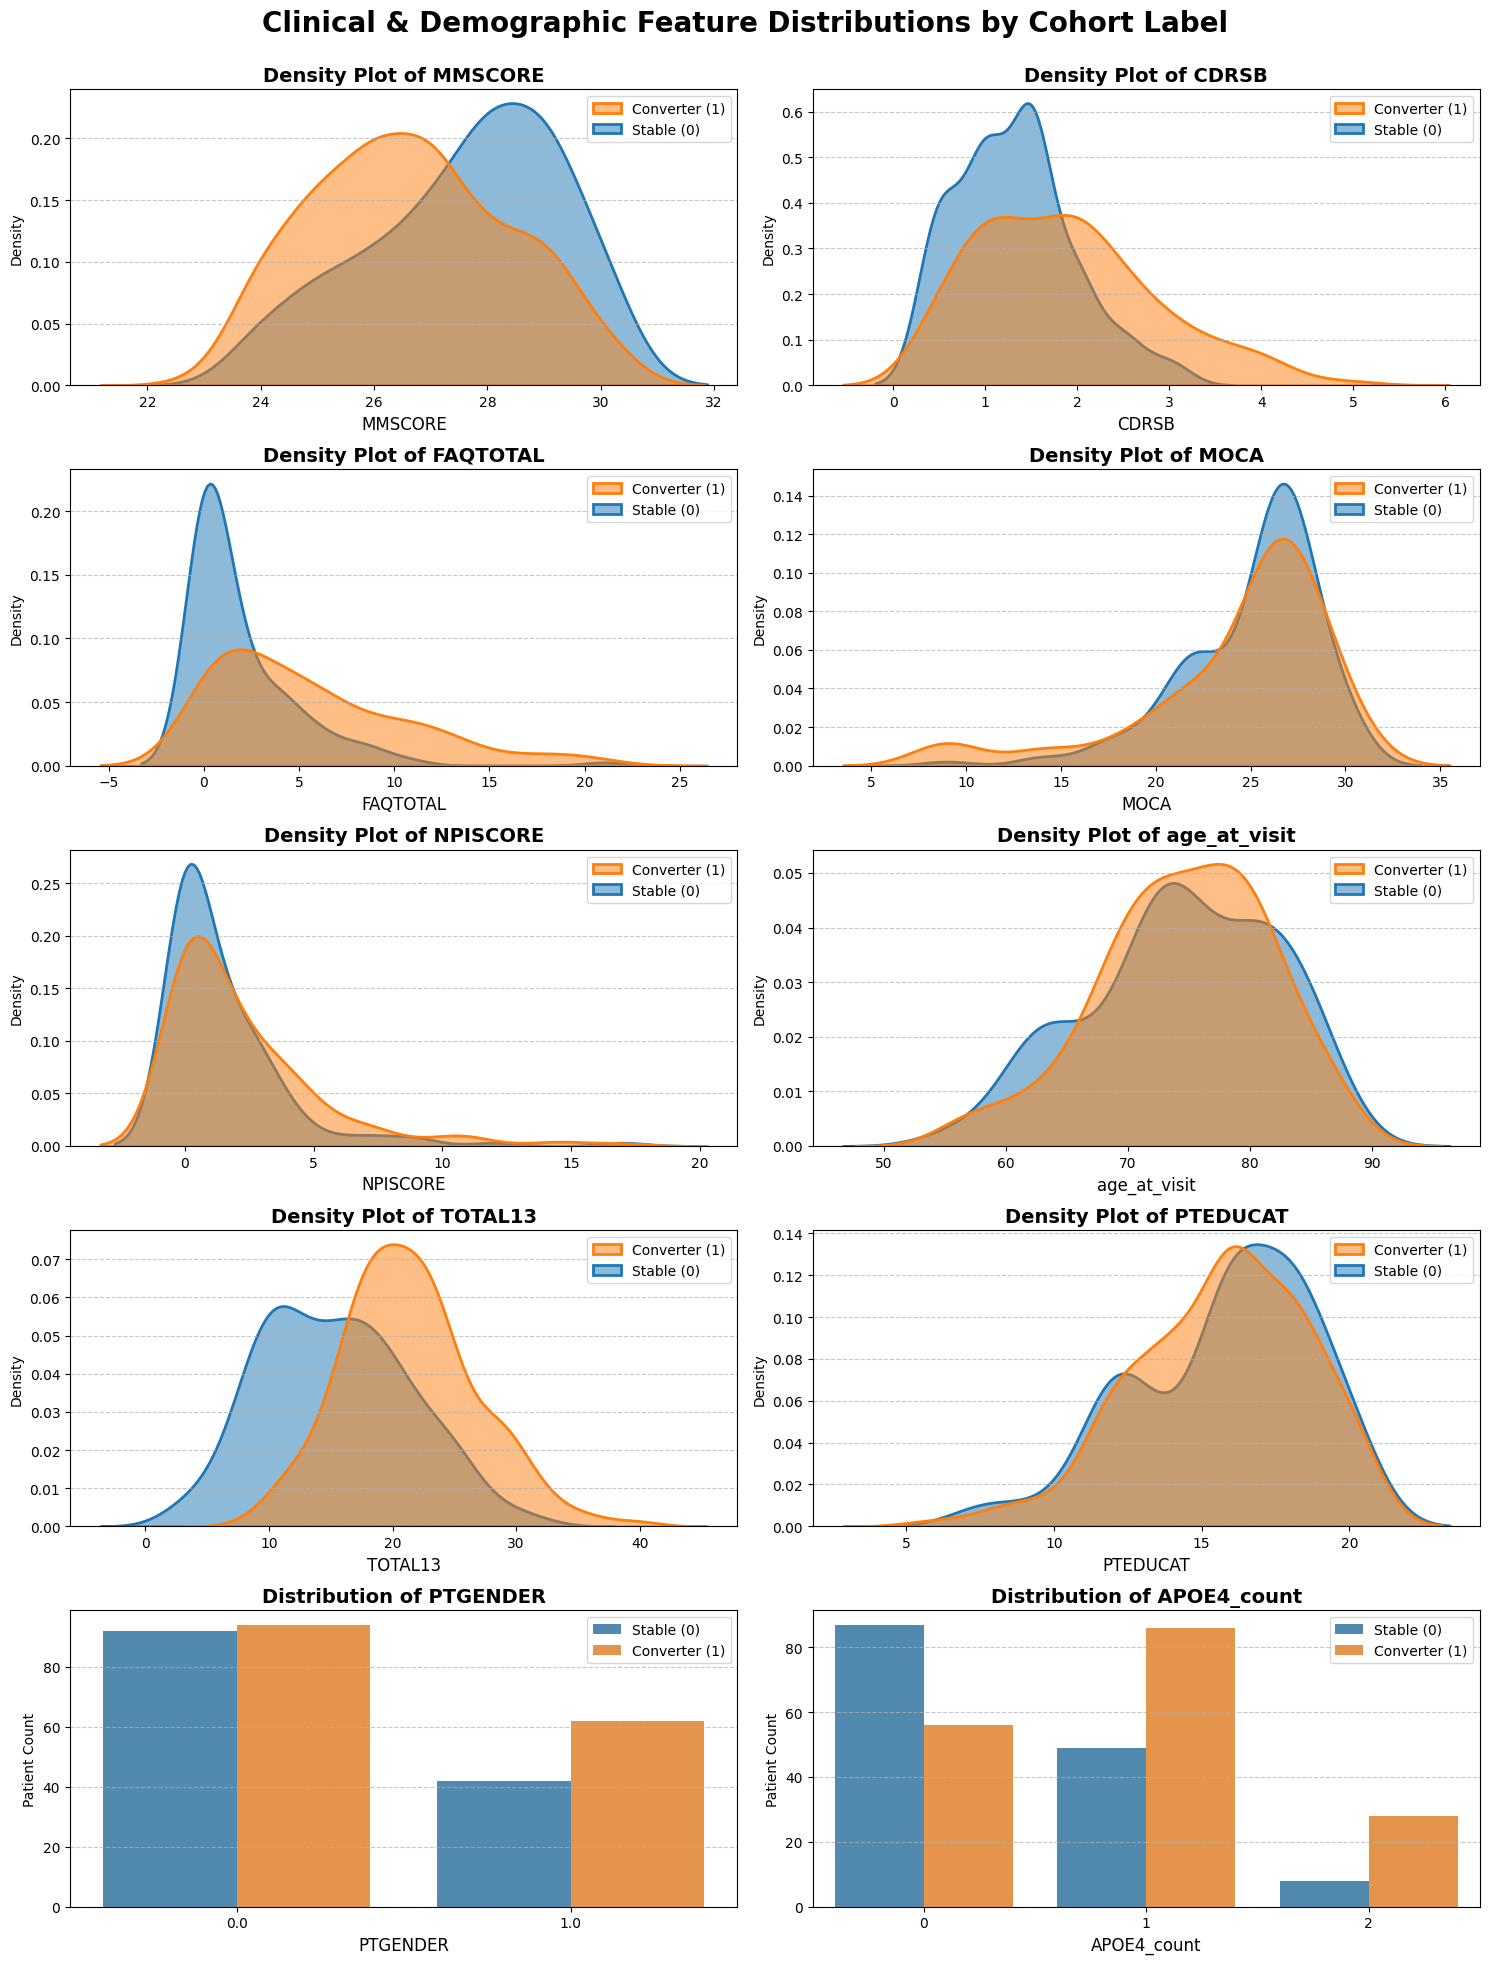

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_cohort_distributions(df, features_list, target_col='label'):
    """
    Plots the distributions of numerical and categorical features in a single figure,
    colored by the binary target class.
    """
    # Create a copy so we don't accidentally modify your original DataFrame
    df_plot = df.copy()
    
    # Map the labels to readable strings for the legend
    df_plot[target_col] = df_plot[target_col].replace({
        0: 'Stable (0)', 
        1: 'Converter (1)'
    })
    
    # Calculate grid size dynamically (2 columns wide, as many rows as needed)
    n_cols = 2
    n_rows = (len(features_list) + 1) // 2
    
    # Initialize the overall figure
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
    fig.suptitle('Clinical & Demographic Feature Distributions by Cohort Label', 
                 fontsize=20, y=0.98, fontweight='bold')
    
    # Flatten the 2D array of axes for easy iteration
    axes = axes.flatten()
    
    # Define a colorblind-friendly blue and orange palette
    palette = {'Stable (0)': '#1f77b4', 'Converter (1)': '#ff7f0e'}
    
    for i, feature in enumerate(features_list):
        ax = axes[i]
        
        # Determine if the feature is categorical/ordinal (few unique values)
        # Using 5 as a threshold (catches PTGENDER, APOE4_count, CDRSB intervals etc.)
        if df_plot[feature].nunique() <= 6:
            # Use a count/bar plot for categorical data
            sns.countplot(
                data=df_plot, 
                x=feature, 
                hue=target_col, 
                palette=palette, 
                ax=ax,
                alpha=0.85
            )
            ax.set_title(f'Distribution of {feature}', fontsize=14, fontweight='bold')
            ax.set_ylabel('Patient Count')
            
        else:
            # Use a filled Density (KDE) plot for continuous numerical data
            sns.kdeplot(
                data=df_plot, 
                x=feature, 
                hue=target_col, 
                fill=True, 
                common_norm=False, # Allows overlapping curves to be scaled independently
                palette=palette,
                ax=ax,
                alpha=0.5,
                linewidth=2
            )
            ax.set_title(f'Density Plot of {feature}', fontsize=14, fontweight='bold')
            ax.set_ylabel('Density')
        
        # Make the charts look a bit cleaner
        ax.set_xlabel(feature, fontsize=12)
        ax.grid(axis='y', linestyle='--', alpha=0.7)
        
        # Clean up the legend title
        if ax.get_legend() is not None:
            ax.get_legend().set_title('')
            
    # Hide any unused subplots at the bottom if the total features are odd
    for j in range(len(features_list), len(axes)):
        fig.delaxes(axes[j])
        
    plt.tight_layout()
    fig.subplots_adjust(top=0.94) # Make room for the main title
    plt.show()

features_to_plot = [
    'MMSCORE', 'CDRSB', 'FAQTOTAL', 'MOCA', 'NPISCORE', 
    'age_at_visit', 'TOTAL13', 'PTEDUCAT', 'PTGENDER', 'APOE4_count'
]

plot_cohort_distributions(baseline_dataset, features_to_plot, target_col='label')

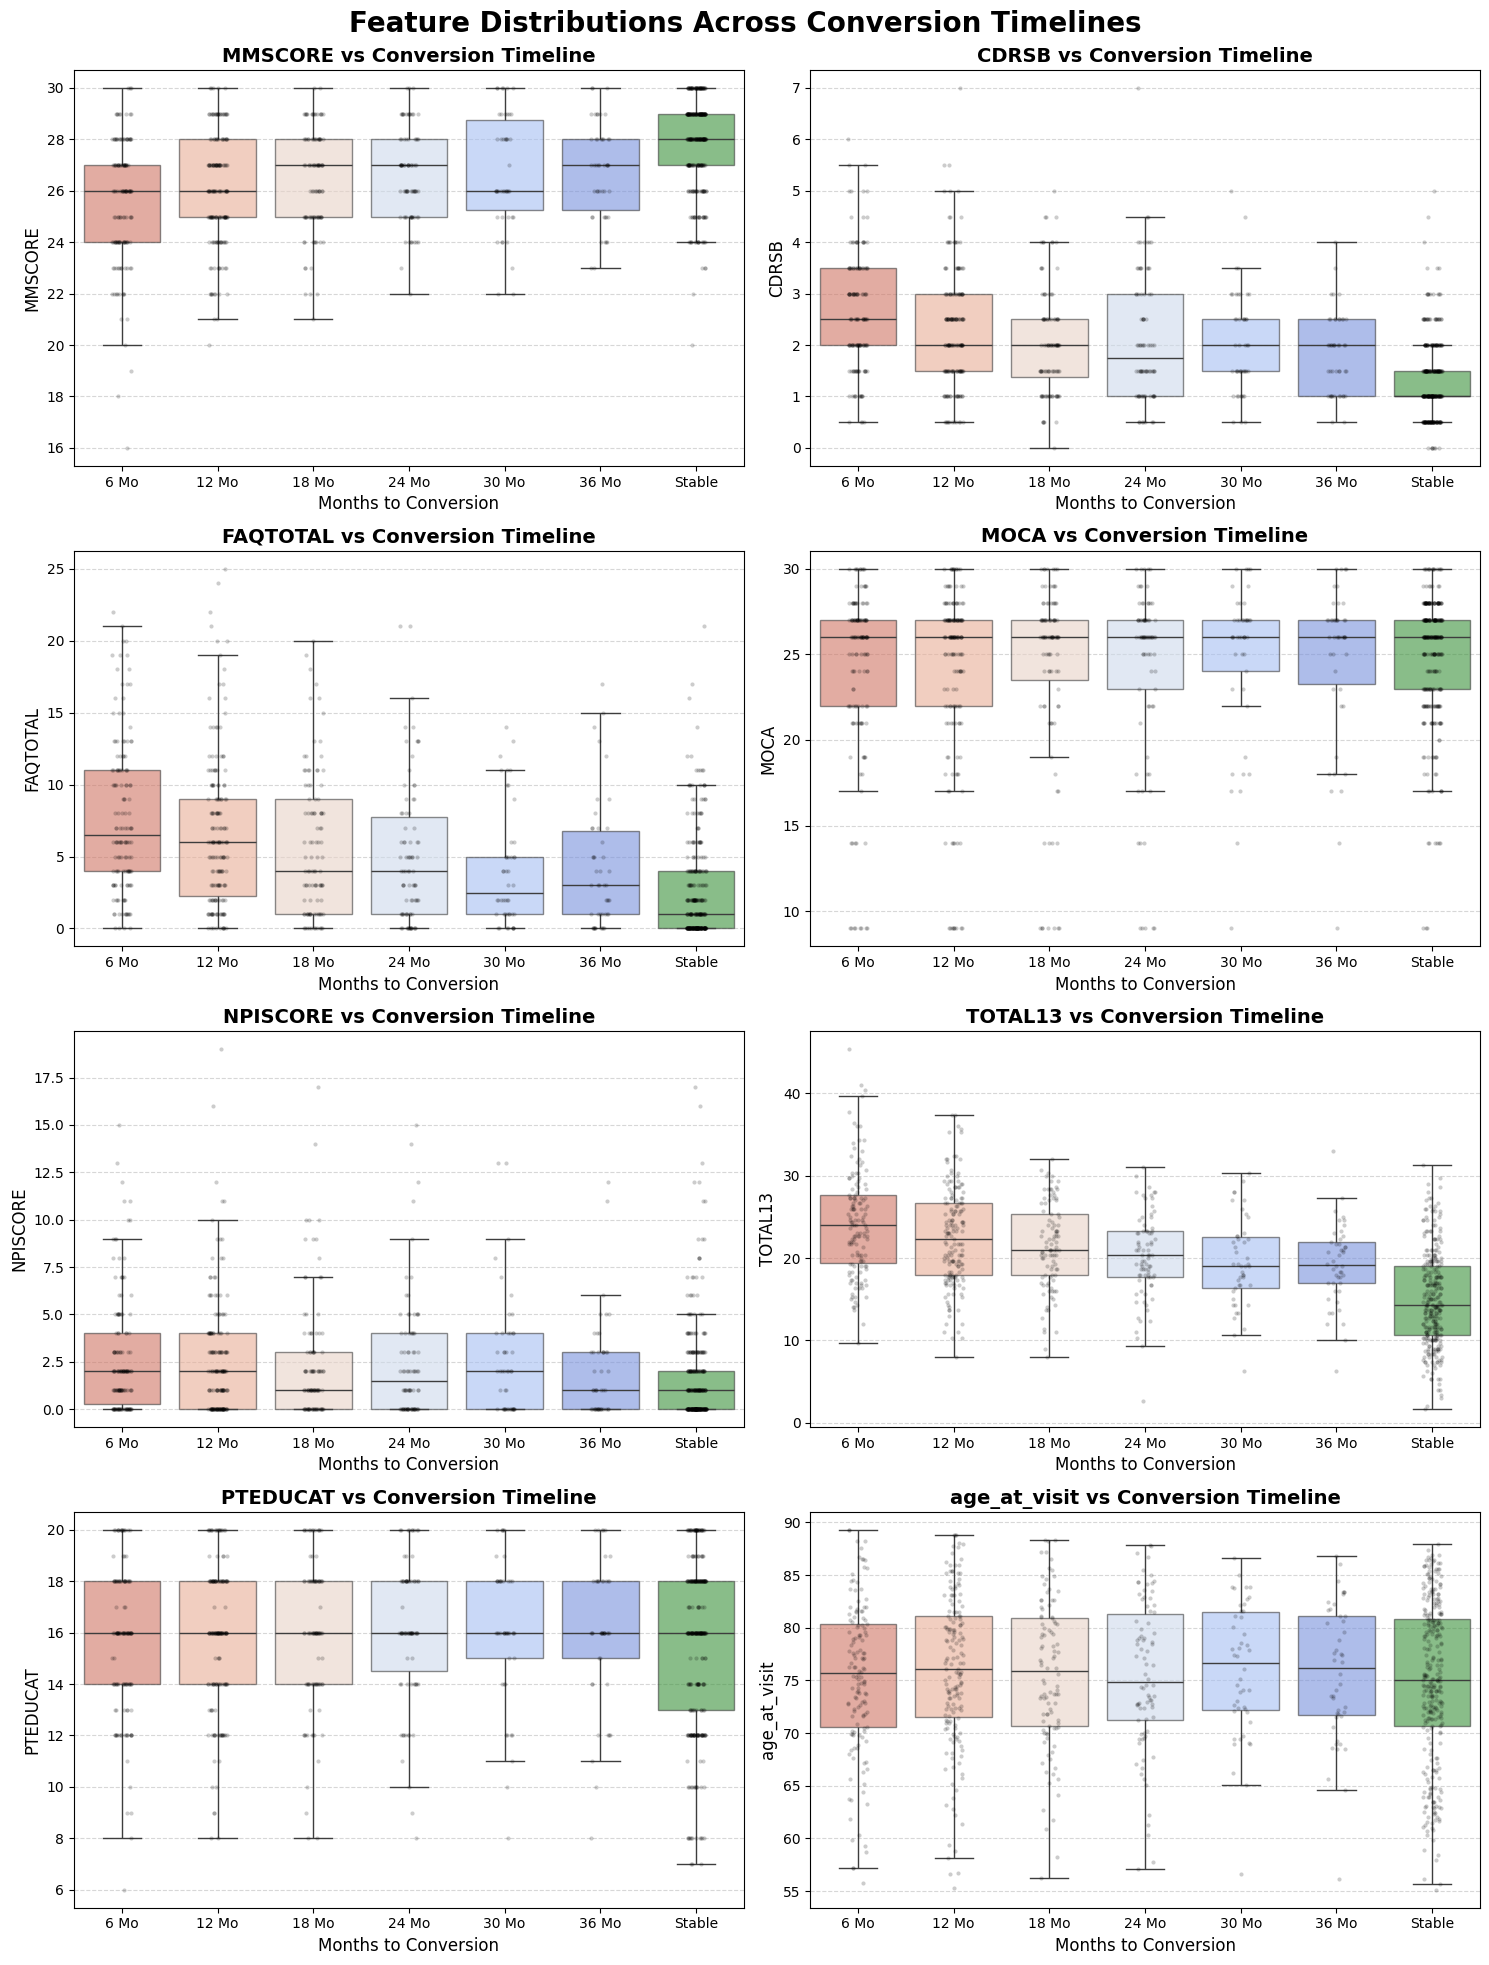

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_features_by_conversion_time(df, features_list, time_col='months_to_conversion'):
    """
    Plots features against the months_to_conversion timeline to see if 
    feature severity correlates with how quickly a patient converts.
    Compliant with Seaborn v0.14+ API.
    """
    df_plot = df.copy()
    
    # 1. Format the timeline for a clean X-axis
    def format_time(val):
        if val == -1:
            return 'Stable'
        else:
            return f"{int(val)} Mo"
            
    df_plot['Timeline'] = df_plot[time_col].apply(format_time)
    
    # 2. Establish a logical chronological order for the X-axis
    unique_months = sorted([int(x) for x in df[time_col].unique() if x != -1])
    time_order = [f"{m} Mo" for m in unique_months] + ['Stable']
    
    # 3. Setup the figure
    n_cols = 2
    n_rows = (len(features_list) + 1) // 2
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
    fig.suptitle('Feature Distributions Across Conversion Timelines', 
                 fontsize=20, y=0.98, fontweight='bold')
    axes = axes.flatten()
    
    # Use a visually distinct palette
    palette = sns.color_palette("coolwarm_r", n_colors=len(time_order)-1) + ["#2ca02c"] 
    
    for i, feature in enumerate(features_list):
        ax = axes[i]
        
        # Updated boxplot for Seaborn v0.14+
        sns.boxplot(
            data=df_plot, 
            x='Timeline', 
            y=feature, 
            hue='Timeline',       # Assign x variable to hue
            order=time_order,
            hue_order=time_order, # Ensure hue follows the same order
            palette=palette,
            ax=ax,
            showfliers=False,
            boxprops={'alpha': 0.6},
            legend=False          # Turn off the redundant legend
        )
        
        # Overlay a stripplot
        sns.stripplot(
            data=df_plot, 
            x='Timeline', 
            y=feature, 
            order=time_order,
            color='black',
            alpha=0.2,
            size=3,
            jitter=True,
            ax=ax
        )
        
        ax.set_title(f'{feature} vs Conversion Timeline', fontsize=14, fontweight='bold')
        ax.set_xlabel('Months to Conversion', fontsize=12)
        ax.set_ylabel(feature, fontsize=12)
        ax.grid(axis='y', linestyle='--', alpha=0.5)

    # Hide unused subplots
    for j in range(len(features_list), len(axes)):
        fig.delaxes(axes[j])
        
    plt.tight_layout()
    fig.subplots_adjust(top=0.95)
    plt.show()

# --- How to run it ---
features_to_plot = [
    'MMSCORE', 'CDRSB', 'FAQTOTAL', 'MOCA', 'NPISCORE', 
    'TOTAL13', 'PTEDUCAT', 'age_at_visit'
]

plot_features_by_conversion_time(final_features_df, features_to_plot)

Datsaset Statistics

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu, chi2_contingency

# Assuming your dataframe is named 'baseline_dataset'
# Define your variables based on their type
continuous_vars = ['age_at_visit', 'PTEDUCAT', 'MMSCORE', 'CDRSB', 
                   'FAQTOTAL', 'MOCA', 'NPISCORE', 'TOTAL13']

categorical_vars = ['PTGENDER', 'APOE4_count']

# Helper function to format continuous variables as "Median (Q1, Q3)"
def format_continuous(series):
    median = series.median()
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    return f"{median:.1f} ({q1:.1f}, {q3:.1f})"

# Helper function to format categorical variables as "Count (%)"
def format_categorical(series, category, total_count):
    count = (series == category).sum()
    percent = (count / total_count) * 100 if total_count > 0 else 0
    return f"{count} ({percent:.1f}%)"

# Initialize lists to store our table rows
table_rows = []

# Split datasets for the statistical tests
df_stable = baseline_dataset[baseline_dataset['label'] == 0]
df_convert = baseline_dataset[baseline_dataset['label'] == 1]
total_n = len(baseline_dataset)
stable_n = len(df_stable)
convert_n = len(df_convert)

# 1. Process Continuous Variables
for var in continuous_vars:
    row = {'Feature': var, 'Level': 'Median (Q1, Q3)'}
    
    # Calculate formatted strings
    row[f'Stable MCI (N={stable_n})'] = format_continuous(df_stable[var].dropna())
    row[f'MCI-to-AD Converters (N={convert_n})'] = format_continuous(df_convert[var].dropna())
    row[f'Total Cohort (N={total_n})'] = format_continuous(baseline_dataset[var].dropna())
    
    # Mann-Whitney U test (dropping NaNs for the test)
    stat_data1 = df_stable[var].dropna()
    stat_data2 = df_convert[var].dropna()
    if len(stat_data1) > 0 and len(stat_data2) > 0:
        _, p_val = mannwhitneyu(stat_data1, stat_data2, alternative='two-sided')
        row['p-value'] = f"{p_val:.3f}" if p_val >= 0.001 else "<0.001"
    else:
        row['p-value'] = "NA"
        
    table_rows.append(row)

# 2. Process Categorical Variables
for var in categorical_vars:
    categories = baseline_dataset[var].dropna().unique()
    categories.sort() # Sort categories logically
    
    # Add a header row for the categorical variable name
    header_row = {'Feature': var, 'Level': '', 
                  f'Stable MCI (N={stable_n})': '', 
                  f'MCI-to-AD Converters (N={convert_n})': '', 
                  f'Total Cohort (N={total_n})': '', 
                  'p-value': ''}
    
    # Chi-square test (calculate once for the whole variable)
    contingency_table = pd.crosstab(baseline_dataset['label'], baseline_dataset[var])
    if contingency_table.size > 0:
        _, p_val, _, _ = chi2_contingency(contingency_table)
        header_row['p-value'] = f"{p_val:.3f}" if p_val >= 0.001 else "<0.001"
    else:
        header_row['p-value'] = "NA"
        
    table_rows.append(header_row)
    
    # Add a row for each category/level
    for cat in categories:
        row = {'Feature': '', 'Level': str(cat)}
        
        row[f'Stable MCI (N={stable_n})'] = format_categorical(df_stable[var], cat, len(df_stable[var].dropna()))
        row[f'MCI-to-AD Converters (N={convert_n})'] = format_categorical(df_convert[var], cat, len(df_convert[var].dropna()))
        row[f'Total Cohort (N={total_n})'] = format_categorical(baseline_dataset[var], cat, len(baseline_dataset[var].dropna()))
        row['p-value'] = '' # Blank out p-values for the sub-levels
        
        table_rows.append(row)

# Construct final DataFrame
table1_df = pd.DataFrame(table_rows)

# Optional mapping to make variable names look nicer for publication
feature_name_mapping = {
    'age_at_visit': 'Age at baseline (years)',
    'PTEDUCAT': 'Education (years)',
    'MMSCORE': 'MMSE Score',
    'CDRSB': 'CDR Sum of Boxes',
    'TOTAL13': 'ADAS-Cog 13',
    'FAQTOTAL': 'FAQ Total Score',
    'MOCA': 'MoCA Score',
    'NPISCORE': 'NPI Score',
    'PTGENDER': 'Gender',
    'APOE4_count': 'APOE4 Allele Count'
}
table1_df['Feature'] = table1_df['Feature'].replace(feature_name_mapping)

# Print the table 
display(table1_df.style.hide(axis="index"))

# Export to CSV 
table1_df.to_csv('Table_S1_ADNI_Baseline.csv', index=False)

Feature,Level,Stable MCI (N=144),MCI-to-AD Converters (N=170),Total Cohort (N=314),p-value
Age at baseline (years),"Median (Q1, Q3)","74.4 (70.4, 80.7)","75.3 (69.8, 79.7)","74.6 (70.1, 80.3)",0.996
Education (years),"Median (Q1, Q3)","16.0 (13.2, 18.0)","16.0 (14.0, 18.0)","16.0 (14.0, 18.0)",0.552
MMSE Score,"Median (Q1, Q3)","28.0 (26.0, 29.0)","27.0 (25.0, 28.0)","27.0 (26.0, 29.0)",<0.001
CDR Sum of Boxes,"Median (Q1, Q3)","1.5 (1.0, 1.5)","2.0 (1.0, 2.5)","1.5 (1.0, 2.0)",<0.001
FAQ Total Score,"Median (Q1, Q3)","1.0 (0.0, 3.0)","4.0 (1.0, 8.0)","2.0 (0.0, 6.0)",<0.001
MoCA Score,"Median (Q1, Q3)","26.0 (23.0, 27.0)","26.0 (22.0, 27.0)","26.0 (22.0, 27.0)",0.556
NPI Score,"Median (Q1, Q3)","1.0 (0.0, 2.0)","1.0 (0.0, 3.0)","1.0 (0.0, 3.0)",0.009
ADAS-Cog 13,"Median (Q1, Q3)","15.3 (10.5, 19.7)","21.0 (17.7, 24.0)","18.7 (14.3, 23.0)",<0.001
Gender,,,,,0.172
,0.0,92 (68.7%),94 (60.3%),186 (64.1%),
